## Chapter 3 — LangChain components (v2026)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/IvanReznikov/LangChain4LifeSciencesHealthcare)


> **LangChain 1.x note:** This notebook has been refreshed to use the current package layout and runnable-oriented patterns where possible. Expect imports such as `langchain_openai`, `langchain_core`, and `langchain_community` instead of older `langchain` monolith imports.

This notebook explains the main building blocks used in LangChain 1.x. The refreshed notes emphasize runnables, prompts, models, parsers, retrievers, and composition patterns rather than older chain abstractions.

**Companion notebook to _LangChain for Life Sciences and Healthcare_.**

## Learning objectives

By the end of this notebook you will be able to: build prompts with `PromptTemplate` and few-shot templates, parse model output into typed Pydantic objects, compose runnables with the `|` operator and `RunnableParallel`, give a model tools with `@tool` and `create_agent`, and understand when to escalate to a Deep Agent.

This notebook demonstrates the core components of the LangChain framework, specifically focusing on applications in life sciences and healthcare. We'll explore prompt templates, output parsers, chains, and runnable components that form the building blocks of LangChain applications.

> **Runtime & cost:** Runs on CPU. The OpenAI/Gemini/Groq calls cost a few cents total; selecting `GROQ` in `API_KEY_PROVIDER` lets you run the LLM sections free with a [Groq API key](https://console.groq.com/keys). Local Hugging Face models download once and then run offline.

### API Configuration

Setting up API keys for external services:
- **OpenAI / GROQ / GEMINI / ANTHROPIC** API for embeddings and language models — pick one with `API_KEY_PROVIDER` below.
- **Hugging Face token** for accessing gated models.

**Where keys come from:** the next cell works in **both Google Colab and locally**. In Colab it reads from *Secrets* (the 🔑 icon). Locally it reads from a `.env` file or environment variables (e.g. `LC4LSH_OPENAI_API_KEY=...`). Never commit your `.env`.

> 💡 Currently **Groq** lets you run this notebook for free — register an [API key](https://console.groq.com/keys) and set `API_KEY_PROVIDER = "GROQ"`.

<details>
<summary>Hidden utility or setup cell</summary>

This cell contains environment configuration, warning suppression, helper utilities, or other notebook plumbing that is useful for execution but not essential for first-pass reading.

</details>

In [1]:
#@title Setting environmental variables
import os

# --- Dual-mode secrets: works in Google Colab AND locally (.env / environment) ---
try:
    from google.colab import userdata  # type: ignore

    IN_COLAB = True
except Exception:
    userdata = None
    IN_COLAB = False

if not IN_COLAB:
    # Local run: load variables from a .env file if present (never commit .env!).
    try:
        from dotenv import load_dotenv

        load_dotenv()
    except Exception:
        pass


def get_secret(name, default=None):
    """Read a secret from Colab Secrets, else from local env/.env, else default."""
    if IN_COLAB and userdata is not None:
        try:
            val = userdata.get(name)
            if val:
                return val
        except Exception:
            pass
    return os.getenv(name, default)


# 👇 Choose your provider 👇
API_KEY_PROVIDER = "OPENAI"  # "GEMINI" | "OPENAI" | "GROQ" | "ANTHROPIC"

if API_KEY_PROVIDER == "OPENAI":
    os.environ["OPENAI_API_KEY"] = get_secret("LC4LSH_OPENAI_API_KEY", "sk-...")
elif API_KEY_PROVIDER == "ANTHROPIC":
    os.environ["ANTHROPIC_API_KEY"] = get_secret(
        "LC4LSH_ANTHROPIC_API_KEY", "sk-ant-..."
    )
elif API_KEY_PROVIDER == "GEMINI":
    os.environ["GOOGLE_API_KEY"] = get_secret("LC4LSH_GOOGLE_API_KEY", "AIza...")
elif API_KEY_PROVIDER == "GROQ":
    os.environ["GROQ_API_KEY"] = get_secret("LC4LSH_GROQ_API_KEY", "gsk_...")

print(
    f"✅ API keys loaded for {API_KEY_PROVIDER} (source: {'Colab Secrets' if IN_COLAB else 'local env/.env'})"
)

# Hugging Face token (optional; needed for gated models)
os.environ["HF_TOKEN"] = get_secret("HF_TOKEN", "") or ""


✅ API keys loaded for OPENAI (source: Colab Secrets)


<details>
<summary>Hidden utility or setup cell</summary>

This cell contains environment configuration, warning suppression, helper utilities, or other notebook plumbing that is useful for execution but not essential for first-pass reading.

</details>

In [2]:
import os, json, random, hashlib, platform, sys

SEED = 42
random.seed(SEED)
try:
    import numpy as np

    np.random.seed(SEED)
except Exception:
    pass

MODEL_ID = os.getenv("LC4LSH_MODEL_ID", "gpt-5-nano")
EMBEDDING_MODEL_ID = os.getenv("LC4LSH_EMBEDDING_MODEL_ID", "text-embedding-3-large")
RUN_METADATA = {
    "seed": SEED,
    "python": sys.version.split()[0],
    "platform": platform.platform(),
    "model_provider": API_KEY_PROVIDER,
    "model_id": MODEL_ID,
}
print(json.dumps(RUN_METADATA, indent=2))

{
  "seed": 42,
  "python": "3.12.13",
  "platform": "Linux-6.6.122+-x86_64-with-glibc2.35",
  "model_provider": "OPENAI",
  "model_id": "gpt-5-nano"
}


This cell advances the **pipeline logic** step by step. Read it by tracking the input, the transformation applied in the middle, and the final output format that the next stage can safely consume.

In [3]:
#@title Setting LangSmith variables
# ========================
# 👇 CONFIGURE HERE 👇
# ========================
LANGSMITH_API_KEY = get_secret("LANGSMITH_API_KEY", "lsv2_pt_...")
LANGSMITH_PROJECT = (
    "lc4lsh-chapter3-langchain-components"  # Traces appear under this name
)
REGION = "US"  # "EU" or "US" - must match your LangSmith account region!
# ========================

if LANGSMITH_API_KEY and LANGSMITH_API_KEY != "lsv2_pt_...":
    os.environ["LANGSMITH_API_KEY"] = LANGSMITH_API_KEY
    os.environ["LANGSMITH_TRACING"] = "true"
    os.environ["LANGSMITH_PROJECT"] = LANGSMITH_PROJECT
    os.environ["LANGSMITH_ENDPOINT"] = (
        "https://eu.api.smith.langchain.com"
        if REGION == "EU"
        else "https://api.smith.langchain.com"
    )
    dashboard = (
        "https://eu.smith.langchain.com"
        if REGION == "EU"
        else "https://smith.langchain.com"
    )
    print(f"✅ LangSmith enabled!")
    print(f"   Region: {REGION} | Project: {LANGSMITH_PROJECT}")
    print(f"   Dashboard: {dashboard}")
else:
    print(
        "⚠️ LangSmith disabled - set LANGSMITH_API_KEY (Colab Secrets or .env) to enable tracing"
    )

✅ LangSmith enabled!
   Region: US | Project: lc4lsh-chapter3-langchain-components
   Dashboard: https://smith.langchain.com


## Package Installation and Setup

<details>
<summary>Optional setup and installation</summary>

Use this only when you are preparing a fresh environment. The notebook content is written for the modern LangChain 1.x package split.

```bash
%pip install -U langchain langgraph langchain-core langchain-openai langchain-community langchain-text-splitters
```

</details>

In [4]:
#@title Installing Python dependencies
# Last validated: 2026-07-21 with the pinned versions below.
# Provider packages are installed so the universal switcher works for whichever
# API_KEY_PROVIDER you choose; only the one you select is exercised at runtime.
%pip install -q \
  "langchain==1.0.0" "langchain-core==1.2.30" "langgraph==1.0.0" \
  "langchain-openai==1.0.0" "langchain-community==0.4.0" "langchain-text-splitters==1.0.0" \
  "langchain-google-genai" "langchain-groq" "langchain-anthropic" \
  "langchain-huggingface" "transformers" "sentencepiece" \
  "deepagents" "python-dotenv" "pydantic>=2.9,<3"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.2/106.2 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 513.0/513.0 kB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.4/155.4 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.5/80.5 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 45.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.6/67.6 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.5/48.5 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.5/42.5 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 38.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 793.7/793.7 kB 31.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0

This cell loads or configures a **model family** from the modern Python AI stack. Pay attention to which component handles preprocessing, which performs inference, and what object type is returned for downstream use.

In [5]:
#@title Verifying versions of Python dependencies
!pip freeze | grep "lang\|openai\|tiktoken|\chroma|\transformers"

google-ai-generativelanguage==0.6.15
google-cloud-language==2.21.0
langchain==1.0.0
langchain-anthropic==1.4.0
langchain-classic==1.0.0
langchain-community==0.4
langchain-core==1.2.30
langchain-google-genai==4.2.2
langchain-groq==1.1.2
langchain-huggingface==1.2.1
langchain-openai==1.0.0
langchain-protocol==0.0.18
langchain-text-splitters==1.0.0
langgraph==1.0.0
langgraph-checkpoint==2.1.2
langgraph-prebuilt==1.0.10
langgraph-sdk==0.2.15
langsmith==0.10.2
libclang==18.1.1
openai==2.45.0


This cell uses the **current LangChain package layout**. In LangChain 1.x, model integrations and core abstractions are split across dedicated packages, which makes dependencies clearer and helps keep notebook examples reproducible.

In [6]:
#@title Importing libraries
from langchain_openai import ChatOpenAI
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_groq import ChatGroq


# 🎛️ UNIVERSAL MODEL SWITCHER
def get_chat_model(provider, temperature=0.7, json_mode=False):
    """Factory function to return the requested LLM."""

    if provider == "OPENAI":
        print(f"🔵 Using OpenAI")
        kwargs = {"response_format": {"type": "json_object"}} if json_mode else {}
        return ChatOpenAI(model=MODEL_ID, model_kwargs=kwargs)

    elif provider == "GEMINI":
        # Using Gemini 2.5 Flash as requested (or latest available)
        print(f"✨ Using Google Gemini (2.5 Flash)")
        return ChatGoogleGenerativeAI(
            model=MODEL_ID,
            temperature=temperature,
            # For JSON mode, we often rely on standard output or mime_type in newer SDKs
            response_mime_type="application/json" if json_mode else None,
        )
    elif provider == "GROQ":
        print(f"⚡ Using Groq")
        # llama-3.3-70b is a strong default
        kwargs = {"response_format": {"type": "json_object"}} if json_mode else {}
        return ChatGroq(model=MODEL_ID, temperature=temperature, model_kwargs=kwargs)

        # list of available models: https://console.groq.com/playground

    # etc
    else:
        raise ValueError(f"Unknown provider: {provider}")

## Structured Output Parsing with Pydantic

In [7]:
from pydantic import BaseModel, Field


class EvidenceBoundFact(BaseModel):
    claim: str
    source_id: str
    source_span: str
    uncertainty: str | None = None
    review_required: bool = True


example_fact = EvidenceBoundFact(
    claim="Synthetic demonstration only",
    source_id="chapter3-demo",
    source_span="Synthetic demonstration only",
)
example_fact.model_dump()

{'claim': 'Synthetic demonstration only',
 'source_id': 'chapter3-demo',
 'source_span': 'Synthetic demonstration only',
 'uncertainty': None,
 'review_required': True}

This cell uses the **current LangChain package layout**. In LangChain 1.x, model integrations and core abstractions are split across dedicated packages, which makes dependencies clearer and helps keep notebook examples reproducible.

In [8]:
#@title Importing libraries
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, pipeline
from langchain_huggingface import HuggingFacePipeline
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser, PydanticOutputParser

from langchain_openai import ChatOpenAI
from pydantic import BaseModel, Field
from typing import List

This cell advances the **pipeline logic** step by step. Read it by tracking the input, the transformation applied in the middle, and the final output format that the next stage can safely consume.

In [9]:
# Define the patient data structure
class PatientAssessment(BaseModel):
    diagnosis: str = Field(description="Primary medical diagnosis")
    pain_level: int = Field(description="Pain level on scale of 0-10")
    symptoms: List[str] = Field(description="List of reported symptoms")
    requires_hospitalization: bool = Field(
        description="Whether patient needs to be hospitalized"
    )


# Create the parser
parser = PydanticOutputParser(pydantic_object=PatientAssessment)

This demonstrates **structured output parsing** - a crucial feature for healthcare applications:

1. **Pydantic Model Definition**:
   - `PatientAssessment` class defines the expected structure of medical assessments
   - Each field has type hints and descriptions for clarity
   - `Field()` provides metadata that helps the LLM understand what's expected

2. **PydanticOutputParser**:
   - Automatically generates format instructions for the LLM
   - Parses the LLM's response into a structured Python object
   - Validates data types and structure

3. **Prompt Template**:
   - `{patient_info}` is the input variable for patient data
   - `{format_instructions}` is automatically populated by the parser
   - The parser tells the LLM exactly how to format its response

4. **Chain Construction**:
   - Uses the `|` operator to create a pipeline: prompt → LLM → parser
   - Each component transforms the data before passing to the next

5. **Type Safety**:
   - The result is a fully typed Python object
   - No need for manual JSON parsing or type conversion
   - Perfect for integration with healthcare systems that require structured data

This approach is essential in both life sciences and healthcare where data consistency and validation are critical.

In [10]:
# Create the prompt template
template = """
Based on the following patient information, provide a medical assessment:
Patient Information: {patient_info}

{format_instructions}
"""

prompt = PromptTemplate(
    template=template,
    input_variables=["patient_info"],
    partial_variables={"format_instructions": parser.get_format_instructions()},
)

This cell uses the **current LangChain package layout**. In LangChain 1.x, model integrations and core abstractions are split across dedicated packages, which makes dependencies clearer and helps keep notebook examples reproducible.

In [11]:
# Set up the LLM via the universal provider switcher (uses MODEL_ID + API_KEY_PROVIDER).
# json_mode requests a JSON-object response where the provider supports it, which
# makes structured-output parsing with Pydantic far more reliable.
llm = get_chat_model(API_KEY_PROVIDER, temperature=0, json_mode=True)

# Create the chain
chain = prompt | llm | parser

🔵 Using OpenAI


This cell demonstrates a **LangChain workflow component**. The key idea is to separate prompt construction, model execution, and output parsing so the pipeline stays modular and easier to test.

In [12]:
# Run the chain
result = chain.invoke(
    {
        "patient_info": "45-year-old male presenting with chest pain, shortness of breath, and fever of 101°F for the past 2 days. History of hypertension."
    }
)

print(f"Diagnosis: {result.diagnosis}")
print(f"Pain Level: {result.pain_level} (Type: {type(result.pain_level)})")
print(f"Symptoms: {result.symptoms} (Type: {type(result.symptoms)})")
print(
    f"Requires Hospitalization: {result.requires_hospitalization} (Type: {type(result.requires_hospitalization)})"
)

Diagnosis: Suspected acute coronary syndrome (unstable angina/NSTEMI) with consideration of infectious etiologies such as pneumonia given fever; requires urgent clinical evaluation.
Pain Level: 8 (Type: <class 'int'>)
Symptoms: ['Chest pain', 'Shortness of breath', 'Fever 101°F for 2 days'] (Type: <class 'list'>)
Requires Hospitalization: True (Type: <class 'bool'>)


This notebook explains the main building blocks used in LangChain 1.x. The refreshed notes emphasize runnables, prompts, models, parsers, retrievers, and composition patterns rather than older chain abstractions.

In [13]:
result, dict(result)

(PatientAssessment(diagnosis='Suspected acute coronary syndrome (unstable angina/NSTEMI) with consideration of infectious etiologies such as pneumonia given fever; requires urgent clinical evaluation.', pain_level=8, symptoms=['Chest pain', 'Shortness of breath', 'Fever 101°F for 2 days'], requires_hospitalization=True),
 {'diagnosis': 'Suspected acute coronary syndrome (unstable angina/NSTEMI) with consideration of infectious etiologies such as pneumonia given fever; requires urgent clinical evaluation.',
  'pain_level': 8,
  'symptoms': ['Chest pain', 'Shortness of breath', 'Fever 101°F for 2 days'],
  'requires_hospitalization': True})

## Hugging Face Model Integration

In [14]:
from transformers import pipeline
from langchain_huggingface import HuggingFacePipeline

# Load the model and tokenizer
model_name = "GT4SD/multitask-text-and-chemistry-t5-base-augm"
model = AutoModelForSeq2SeqLM.from_pretrained(model_name)
tokenizer = AutoTokenizer.from_pretrained(model_name)

pipe = pipeline(
    task="text-generation",
    model=model,
    tokenizer=tokenizer,
    # max_new_tokens=512,
)

llm = HuggingFacePipeline(pipeline=pipe)

config.json:   0%|          | 0.00/1.48k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  892MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/257 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/2.37k [00:00<?, ?B/s]

spiece.model: reconstructing file:   0%|          |  0.00B /  792kB            

spiece.model: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/2.20k [00:00<?, ?B/s]

[transformers] The model 'T5ForConditionalGeneration' is not supported for text-generation. Supported models are ['PeftModelForCausalLM', 'AfmoeForCausalLM', 'ApertusForCausalLM', 'ArceeForCausalLM', 'AriaTextForCausalLM', 'BambaForCausalLM', 'BartForCausalLM', 'BertLMHeadModel', 'BertGenerationDecoder', 'BigBirdForCausalLM', 'BigBirdPegasusForCausalLM', 'BioGptForCausalLM', 'BitNetForCausalLM', 'BlenderbotForCausalLM', 'BlenderbotSmallForCausalLM', 'BloomForCausalLM', 'BltForCausalLM', 'CamembertForCausalLM', 'CodeGenForCausalLM', 'CohereForCausalLM', 'Cohere2ForCausalLM', 'Cohere2MoeForCausalLM', 'CpmAntForCausalLM', 'CTRLLMHeadModel', 'CwmForCausalLM', 'Data2VecTextForCausalLM', 'DbrxForCausalLM', 'DeepseekV2ForCausalLM', 'DeepseekV3ForCausalLM', 'DeepseekV32ForCausalLM', 'DeepseekV4ForCausalLM', 'DiffLlamaForCausalLM', 'DogeForCausalLM', 'Dots1ForCausalLM', 'ElectraForCausalLM', 'Emu3ForCausalLM', 'ErnieForCausalLM', 'Ernie4_5ForCausalLM', 'Ernie4_5_MoeForCausalLM', 'Exaone4ForCaus

> **LangChain 1.x note:** This notebook has been refreshed to use the current package layout and runnable-oriented patterns where possible. Expect imports such as `langchain_openai`, `langchain_core`, and `langchain_community` instead of older `langchain` monolith imports.

This demonstrates **local model integration** using Hugging Face, which is crucial for healthcare applications with privacy concerns:

1. **Specialized Chemistry Model**:
   - `GT4SD/multitask-text-and-chemistry-t5-base-augm` is a T5 model trained on chemistry and text tasks
   - Perfect for pharmaceutical and chemical research applications
   - Runs completely offline once downloaded

2. **Pipeline Configuration**:
   - `temperature=0`: Ensures deterministic, reproducible outputs (critical in healthcare)
   - `max_length=512`: Limits response length
   - `num_beams=5`: Uses beam search for higher quality outputs

3. **LangChain Integration**:
   - `HuggingFacePipeline` wraps the Hugging Face pipeline
   - Makes it compatible with LangChain's chain architecture
   - Enables consistent interface across different model providers

4. **Prompt Engineering Comparison**:
   - **Basic prompt**: Minimal context, relies on model's training
   - **Prompt 1**: Adds role context ("as a chemist")
   - **Prompt 2**: More elaborate role-playing with professional context
   - Demonstrates how prompt engineering affects model behavior

5. **Chain Architecture**:
   - Each chain follows the same pattern: prompt → model → output parser
   - `StrOutputParser()` extracts the text from the model's response
   - Shows how different prompts can be easily tested with the same underlying model

This approach is valuable for healthcare organizations that need to keep sensitive data on-premises while still leveraging AI capabilities.

In [15]:
# Define prompt templates
basic_prompt = PromptTemplate.from_template("{input_text}")
prompt1 = PromptTemplate.from_template(
    "Continue the following phrase as a chemist: {input_text}"
)
prompt2 = PromptTemplate.from_template(
    "You are a professional chemistry researcher.\nFinish the following sentence: {input_text}"
)

This cell demonstrates a **LangChain workflow component**. The key idea is to separate prompt construction, model execution, and output parsing so the pipeline stays modular and easier to test.

In [16]:
# Create chains for each prompt
basic_chain = basic_prompt | llm | StrOutputParser()
prompt1_chain = prompt1 | llm | StrOutputParser()
prompt2_chain = prompt2 | llm | StrOutputParser()

This cell demonstrates a **LangChain workflow component**. The key idea is to separate prompt construction, model execution, and output parsing so the pipeline stays modular and easier to test.

In [17]:
# The text to be continued
TEXT = "The formula of dihydrogen monoxide is "

# Run the chains
basic_result = basic_chain.invoke({"input_text": TEXT})
prompt1_result = prompt1_chain.invoke({"input_text": TEXT})
prompt2_result = prompt2_chain.invoke({"input_text": TEXT})

[transformers] Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


This notebook explains the main building blocks used in LangChain 1.x. The refreshed notes emphasize runnables, prompts, models, parsers, retrievers, and composition patterns rather than older chain abstractions.

In [18]:
print("Basic prompt result:", basic_result)
print("=" * 20)
print("Prompt 1 result:", prompt1_result)
print("=" * 20)
print("Prompt 2 result:", prompt2_result)

Basic prompt result: The formula of dihydrogen monoxide is 
Prompt 1 result: Continue the following phrase as a chemist: The formula of dihydrogen monoxide is ]I.[C].[Li]CCCC
Prompt 2 result: You are a professional chemistry researcher.
Finish the following sentence: The formula of dihydrogen monoxide is 1(C)C.[O-][Mn](=O)(=O)=O


As you can see above, prompts matter!

## Few-Shot Learning for Medical Reasoning

In [19]:
from langchain_core.prompts import FewShotPromptTemplate, PromptTemplate

examples = [
    {
        "question": "Is Penicillin effective against E. coli?",
        "answer": """
Are follow-up questions needed here: Yes.
Follow up: What class of antibiotics does Penicillin belong to?
Intermediate answer: Penicillin belongs to the beta-lactam class of antibiotics.
Follow up: What mechanism of action does Penicillin have?
Intermediate answer: Penicillin interferes with the synthesis of the bacterial
cell wall.
Follow up: Is E. coli resistant to beta-lactam antibiotics?
Intermediate answer: Many strains of E. coli have developed resistance to
beta-lactam antibiotics, including Penicillin.
So the final answer is: Penicillin is generally not effective against E. coli due
to resistance.
""",
    },
    {
        "question": "Do Aspirin and Ibuprofen have the same mechanism of action?",
        "answer": """
Are follow-up questions needed here: Yes.
Follow up: What is the mechanism of action of aspirin?
Intermediate Answer: Aspirin works by inhibiting the enzyme cyclooxygenase (COX),
which reduces the formation of prostaglandins and thromboxanes, leading to its
anti-inflammatory and anticoagulant effects.
Follow up: What is the mechanism of action of Ibuprofen?
Intermediate Answer: Ibuprofen also inhibits the cyclooxygenase (COX) enzyme,
reducing the production of prostaglandins.
So the final answer is: Yes, both Aspirin and Ibuprofen have the same mechanism of
action, which is the inhibition of the COX enzyme.
""",
    },
]

This demonstrates **few-shot learning** with **chain-of-thought reasoning** - essential for complex medical reasoning:

1. **Few-Shot Learning Concept**:
   - Provides the model with examples of the desired reasoning pattern
   - Teaches the model to break down complex medical questions systematically
   - More effective than zero-shot prompting for specialized domains

2. **Chain-of-Thought Reasoning**:
   - Each example shows step-by-step logical progression
   - "Follow up questions" break complex problems into manageable parts
   - "Intermediate answers" provide reasoning transparency
   - Critical for medical applications where reasoning must be auditable

3. **Medical Domain Examples**:
   - **Example 1**: Antibiotic resistance reasoning
   - **Example 2**: Drug mechanism comparison
   - Both examples demonstrate multi-step medical reasoning

4. **Template Structure**:
   - `example_prompt`: Formats each individual example
   - `FewShotPromptTemplate`: Combines all examples with the new question
   - `suffix`: Adds the new question in the same format

5. **Comparison Study**:
   - First call: Direct LLM invocation without examples
   - Second call: Using the few-shot chain
   - Shows how examples improve the quality and structure of medical reasoning

6. **Complex Medical Question**:
   - Cancer genetics question requires multi-layered understanding
   - Tests the model's ability to apply the learned reasoning pattern
   - Demonstrates how few-shot learning scales to complex scenarios

In [20]:
# setting the prompt template to process the examples list
example_prompt = PromptTemplate(
    input_variables=["question", "answer"], template="Question: {question}\n{answer}"
)

# setting the prompt template to be used with the LLM
prompt = FewShotPromptTemplate(
    examples=examples,
    example_prompt=example_prompt,
    suffix="Question: {input}",
    input_variables=["input"],
)

This notebook explains the main building blocks used in LangChain 1.x. The refreshed notes emphasize runnables, prompts, models, parsers, retrievers, and composition patterns rather than older chain abstractions.

In [21]:
TEXT = "How do genetic mutations in oncogenes and tumor suppressor genes interact to drive the progression of metastatic cancer?"

This notebook explains the main building blocks used in LangChain 1.x. The refreshed notes emphasize runnables, prompts, models, parsers, retrievers, and composition patterns rather than older chain abstractions.

In [22]:
llm = get_chat_model(API_KEY_PROVIDER)

🔵 Using OpenAI


This cell demonstrates a **LangChain workflow component**. The key idea is to separate prompt construction, model execution, and output parsing so the pipeline stays modular and easier to test.

In [23]:
llm.invoke(TEXT).content

'Short answer:\nMutations that activate oncogenes push cells to grow, survive, and rewire metabolism, while mutations that inactivate tumor suppressor genes remove the brakes that would normally stop abnormal growth or repair DNA. When these two types of mutations co-occur and interact, they not only drive primary tumor growth but also enable the cellular changes and the harsh survival needed for cancer cells to invade, survive in the bloodstream, colonize distant sites, and form metastases.\n\nDetailed explanation:\n\n- Oncogenes vs. tumor suppressors (TSGs)\n  - Oncogenes (gain-of-function): when mutated or overexpressed, they promote proliferation, survival, angiogenesis, and metabolic changes. Examples: KRAS, EGFR, BRAF, MYC, MET.\n  - Tumor suppressors (loss-of-function): when inactivated, they normally restrain cell growth, promote DNA repair, or trigger cell death/senescence. Examples: TP53, RB1, PTEN, CDKN2A (p16/INK4A), BRCA1/2, APC.\n\n- How they interact to promote cancer pr

This cell demonstrates a **LangChain workflow component**. The key idea is to separate prompt construction, model execution, and output parsing so the pipeline stays modular and easier to test.

In [24]:
basic_chain = prompt | llm | StrOutputParser()
basic_chain.invoke({"input": TEXT})

'Short answer: Oncogene activation and tumor suppressor loss cooperate to push cancer cells from a primary tumor toward metastasis by promoting growth, survival, genetic instability, and invasive behavior.\n\nKey concepts:\n- Oncogenes vs tumor suppressors\n  - Oncogenes (when mutated or overexpressed) drive proliferative and survival signaling (e.g., RAS/MAPK, PI3K/AKT/mTOR, MYC).\n  - Tumor suppressor genes (when inactivated) normally restrain growth, promote DNA repair, and induce apoptosis (e.g., TP53, RB1, PTEN, BRCA1/2, CDKN2A).\n\nHow they interact to promote metastasis:\n- Genomic instability and mutation accumulation\n  - Loss of p53 or other DNA repair/tumor-suppressor functions increases genomic instability. More mutations mean more chances to acquire metastatic traits (invasion, EMT, survival under stress).\n- Escape from growth suppression and enhanced signaling\n  - Oncogene activation keeps growth signals running even when checkpoints would normally halt the cell cycle. 

## Runnable Components and Composition

In [25]:
from langchain_core.runnables import RunnableLambda, RunnableParallel

normalize = RunnableLambda(lambda x: " ".join(x.split()))
inspect = RunnableParallel(normalized=normalize, chars=RunnableLambda(len))
inspect.invoke(
    "  life science   pipeline ",
    config={
        "tags": ["chapter3", "2026"],
        "metadata": {"dataset": "demo", "seed": SEED},
    },
)

{'normalized': 'life science pipeline', 'chars': 26}

This cell uses the **current LangChain package layout**. In LangChain 1.x, model integrations and core abstractions are split across dedicated packages, which makes dependencies clearer and helps keep notebook examples reproducible.

In [26]:
from langchain_core.runnables import RunnableLambda

# A RunnableSequence constructed using the `|` operator
sequence = RunnableLambda(lambda x: x + 1) | RunnableLambda(lambda x: x * 2)

> **LangChain 1.x note:** This notebook has been refreshed to use the current package layout and runnable-oriented patterns where possible. Expect imports such as `langchain_openai`, `langchain_core`, and `langchain_community` instead of older `langchain` monolith imports.

This section introduces **LangChain's Runnable interface** - the foundation for building complex AI workflows:

1. **RunnableLambda**:
   - Wraps simple Python functions into LangChain-compatible components
   - Enables functional programming patterns in AI pipelines
   - Provides consistent interfaces for invoke, batch, and stream operations

2. **Sequential Composition**:
   - `|` operator chains operations left-to-right
   - Output of first operation becomes input of second
   - Similar to Unix pipes but for AI workflows

3. **Parallel Composition**:
   - Dictionary syntax creates parallel branches
   - Single input is processed by multiple functions simultaneously
   - Results are combined into a dictionary with named outputs

4. **Batch Processing**:
   - `batch()` method processes multiple inputs efficiently
   - Maintains the same transformation logic across all inputs
   - Essential for processing large datasets in healthcare applications

5. **Flexibility**:
   - Can combine sequential and parallel operations
   - Building blocks for complex medical data processing pipelines
   - Enables sophisticated workflows while maintaining readability

This pattern is foundational for building scalable healthcare AI systems where data needs to flow through multiple processing steps.

In [27]:
sequence.invoke(1)  # 4

4

This cell advances the **pipeline logic** step by step. Read it by tracking the input, the transformation applied in the middle, and the final output format that the next stage can safely consume.

In [28]:
sequence.batch([1, 2, 3])  # [4, 6, 8]

[4, 6, 8]

This cell demonstrates a **LangChain workflow component**. The key idea is to separate prompt construction, model execution, and output parsing so the pipeline stays modular and easier to test.

In [29]:
# A sequence that contains a RunnableParallel constructed using a dict literal
sequence = RunnableLambda(lambda x: x + 1) | {
    "mul_2": RunnableLambda(lambda x: x * 2),
    "mul_5": RunnableLambda(lambda x: x * 5),
}

This cell demonstrates a **LangChain workflow component**. The key idea is to separate prompt construction, model execution, and output parsing so the pipeline stays modular and easier to test.

In [30]:
sequence.invoke(1)

{'mul_2': 4, 'mul_5': 10}

This cell advances the **pipeline logic** step by step. Read it by tracking the input, the transformation applied in the middle, and the final output format that the next stage can safely consume.

In [31]:
sequence.batch([1, 2, 3])  # [4, 6, 8]

[{'mul_2': 4, 'mul_5': 10},
 {'mul_2': 6, 'mul_5': 15},
 {'mul_2': 8, 'mul_5': 20}]

> **LangChain 1.x note:** This notebook has been refreshed to use the current package layout and runnable-oriented patterns where possible. Expect imports such as `langchain_openai`, `langchain_core`, and `langchain_community` instead of older `langchain` monolith imports.

## Practical Example: Temperature Conversion with LangChain

In [32]:
from langchain_core.runnables import RunnableLambda


# Define temperature conversion functions
def kelvin_to_celsius(kelvin_temp):
    """Convert Kelvin to Celsius"""
    return kelvin_temp - 273.15


def celsius_to_fahrenheit(celsius_temp):
    """Convert Celsius to Fahrenheit"""
    return (celsius_temp * 9 / 5) + 32


def format_temperature_result(temp_dict):
    """Format the temperature conversion results"""
    return {
        "original_kelvin": temp_dict["kelvin"],
        "celsius": round(temp_dict["celsius"], 2),
        "fahrenheit": round(temp_dict["fahrenheit"], 2),
        "formatted_output": f"{temp_dict['kelvin']}K = {round(temp_dict['celsius'], 2)}°C = {round(temp_dict['fahrenheit'], 2)}°F",
    }


# Create RunnableLambda components
kelvin_to_celsius_runnable = RunnableLambda(kelvin_to_celsius)
celsius_to_fahrenheit_runnable = RunnableLambda(celsius_to_fahrenheit)
format_result_runnable = RunnableLambda(format_temperature_result)

> **LangChain 1.x note:** This notebook has been refreshed to use the current package layout and runnable-oriented patterns where possible. Expect imports such as `langchain_openai`, `langchain_core`, and `langchain_community` instead of older `langchain` monolith imports.

This comprehensive example demonstrates **practical application of LangChain Runnables** for temperature conversion with medical context:

1. **Function Definition**:
   - Pure Python functions for temperature conversions
   - Follows single responsibility principle
   - Easy to test and maintain

2. **RunnableLambda Wrapping**:
   - Converts Python functions into LangChain components
   - Enables composition with other LangChain components
   - Provides consistent interface (invoke, batch, stream)

3. **Sequential Processing**:
   - Demonstrates step-by-step transformation
   - Kelvin → Celsius → Fahrenheit pipeline
   - Maintains intermediate results for transparency

4. **Parallel Processing**:
   - Multiple conversions happen simultaneously
   - More efficient for independent calculations
   - Shows different architectural approaches

5. **Data Structure Management**:
   - Dictionary-based data flow
   - Preserves original values alongside conversions
   - Structured output for downstream processing

6. **Batch Processing**:
   - Efficiently processes multiple temperatures
   - Maintains consistent transformation logic
   - Essential for processing large datasets

7. **Medical Application**:
   - Body temperature analysis with clinical context
   - Fever detection and categorization
   - Demonstrates real-world healthcare application

8. **Composition Patterns**:
   - Shows how to combine different types of operations
   - Parallel and sequential processing in the same pipeline
   - Scalable architecture for complex medical workflows

In [33]:
# Method 1: Sequential conversion (Kelvin → Celsius → Fahrenheit)
sequential_conversion = (
    RunnableLambda(lambda x: x)  # Pass through the input
    | {
        "kelvin": RunnableLambda(lambda x: x),  # Keep original value
        "celsius": kelvin_to_celsius_runnable,  # Convert to Celsius
    }
    | RunnableLambda(
        lambda x: {
            "kelvin": x["kelvin"],
            "celsius": x["celsius"],
            "fahrenheit": celsius_to_fahrenheit(
                x["celsius"]
            ),  # Convert Celsius to Fahrenheit
        }
    )
    | format_result_runnable
)


# Method 2: Direct conversion functions
def kelvin_to_fahrenheit_direct(kelvin_temp):
    """Direct conversion from Kelvin to Fahrenheit"""
    celsius = kelvin_temp - 273.15
    fahrenheit = (celsius * 9 / 5) + 32
    return fahrenheit


# Create parallel conversion chain
parallel_conversion = (
    RunnableLambda(lambda x: x)
    | {
        "kelvin": RunnableLambda(lambda x: x),
        "celsius": kelvin_to_celsius_runnable,
        "fahrenheit": RunnableLambda(kelvin_to_fahrenheit_direct),
    }
    | format_result_runnable
)

This cell demonstrates a **LangChain workflow component**. The key idea is to separate prompt construction, model execution, and output parsing so the pipeline stays modular and easier to test.

In [34]:
# Test with various temperatures
test_temperatures = [
    273.15,
    300,
    310.15,
    373.15,
]  # 0°C, ~27°C, ~37°C (body temp), 100°C

print("=== Sequential Conversion Results ===")
for temp in test_temperatures:
    result = sequential_conversion.invoke(temp)
    print(f"Sequential: {result['formatted_output']}")

print("\n=== Parallel Conversion Results ===")
for temp in test_temperatures:
    result = parallel_conversion.invoke(temp)
    print(f"Parallel: {result['formatted_output']}")

# Batch processing example
print("\n=== Batch Processing ===")
batch_results = parallel_conversion.batch(test_temperatures)
for result in batch_results:
    print(f"Batch: {result['formatted_output']}")

# Medical context example: Converting body temperature readings
print("\n=== Medical Context: Body Temperature Analysis ===")
body_temps_kelvin = [
    309.15,
    310.15,
    311.15,
    312.15,
]  # Range of body temperatures in Kelvin

medical_analysis = RunnableLambda(lambda x: x) | {
    "temperature_data": parallel_conversion,
    "medical_assessment": RunnableLambda(
        lambda temp_k: {
            "normal_range": 36.1 <= (temp_k - 273.15) <= 37.2,
            "fever_status": (
                "Fever"
                if (temp_k - 273.15) > 37.2
                else "Normal" if (temp_k - 273.15) >= 36.1 else "Hypothermia"
            ),
            "celsius_value": round(temp_k - 273.15, 1),
        }
    ),
}

=== Sequential Conversion Results ===
Sequential: 273.15K = 0.0°C = 32.0°F
Sequential: 300K = 26.85°C = 80.33°F
Sequential: 310.15K = 37.0°C = 98.6°F
Sequential: 373.15K = 100.0°C = 212.0°F

=== Parallel Conversion Results ===
Parallel: 273.15K = 0.0°C = 32.0°F
Parallel: 300K = 26.85°C = 80.33°F
Parallel: 310.15K = 37.0°C = 98.6°F
Parallel: 373.15K = 100.0°C = 212.0°F

=== Batch Processing ===
Batch: 273.15K = 0.0°C = 32.0°F
Batch: 300K = 26.85°C = 80.33°F
Batch: 310.15K = 37.0°C = 98.6°F
Batch: 373.15K = 100.0°C = 212.0°F

=== Medical Context: Body Temperature Analysis ===


This cell demonstrates a **LangChain workflow component**. The key idea is to separate prompt construction, model execution, and output parsing so the pipeline stays modular and easier to test.

In [35]:
for temp_k in body_temps_kelvin:
    analysis = medical_analysis.invoke(temp_k)
    temp_data = analysis["temperature_data"]
    medical_data = analysis["medical_assessment"]

    print(f"Temperature: {temp_data['formatted_output']}")
    print(f"  Medical Status: {medical_data['fever_status']}")
    print(f"  Normal Range: {medical_data['normal_range']}")
    print()

Temperature: 309.15K = 36.0°C = 96.8°F
  Medical Status: Hypothermia
  Normal Range: False

Temperature: 310.15K = 37.0°C = 98.6°F
  Medical Status: Normal
  Normal Range: True

Temperature: 311.15K = 38.0°C = 100.4°F
  Medical Status: Fever
  Normal Range: False

Temperature: 312.15K = 39.0°C = 102.2°F
  Medical Status: Fever
  Normal Range: False



## Tools, agents, and Deep Agents

Use an agent only when tool choice is genuinely variable; start with deterministic runnables for known flows.

In [36]:
from langchain.tools import tool


@tool
def search_synthetic_evidence(query: str) -> list[dict]:
    """Search a tiny local synthetic corpus; returns records, not clinical advice."""
    corpus = [
        {
            "id": "demo-1",
            "text": "A simulated assay reported an 18 percent signal reduction.",
        }
    ]
    terms = set(query.lower().split())
    return [r for r in corpus if terms & set(r["text"].lower().split())]


search_synthetic_evidence.invoke({"query": "simulated assay"})

[{'id': 'demo-1',
  'text': 'A simulated assay reported an 18 percent signal reduction.'}]

This cell uses the **current LangChain package layout**. In LangChain 1.x, model integrations and core abstractions are split across dedicated packages, which makes dependencies clearer and helps keep notebook examples reproducible.

In [37]:
from langchain.agents import create_agent
from langchain_openai import ChatOpenAI

agent = create_agent(
    get_chat_model(API_KEY_PROVIDER),
    [search_synthetic_evidence],
    system_prompt="Use tools before factual claims; state insufficient evidence when no record is returned. No medical decisions.",
)

🔵 Using OpenAI


This cell demonstrates a **LangChain workflow component**. The key idea is to separate prompt construction, model execution, and output parsing so the pipeline stays modular and easier to test.

In [38]:
print(
    agent.invoke(
        {
            "messages": [
                {"role": "user", "content": "What did the simulated assay report?"}
            ]
        }
    )
)

{'messages': [HumanMessage(content='What did the simulated assay report?', additional_kwargs={}, response_metadata={}, id='d40b4673-a2d5-4aa3-ab44-fca0c74de242'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 221, 'prompt_tokens': 164, 'total_tokens': 385, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 192, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-nano-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-E6bSMv7HxLRkedTojVc4CQuNDYhbV', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019fa8c1-2562-7131-9442-e39d6bf3ff59-0', tool_calls=[{'name': 'search_synthetic_evidence', 'args': {'query': 'simulated assay report'}, 'id': 'call_88zQXo19Li2VgdPOJY67KaMv', 'type': 'tool_call'}], invalid_

<details>
<summary>Optional setup and installation</summary>

Use this only when you are preparing a fresh environment. The notebook content is written for the modern LangChain 1.x package split.

```bash
%pip install -U langchain langgraph langchain-core langchain-openai langchain-community langchain-text-splitters
```

</details>

In [39]:
!pip install -q deepagents

This notebook explains the main building blocks used in LangChain 1.x. The refreshed notes emphasize runnables, prompts, models, parsers, retrievers, and composition patterns rather than older chain abstractions.

In [40]:
from deepagents import create_deep_agent

# Use for reviewed evidence-map/workspace tasks, not autonomous scientific or clinical decisions.
deep_agent = create_deep_agent(
    model=f"openai:{MODEL_ID}",
    tools=[search_synthetic_evidence],
    system_prompt="Build an evidence map and preserve uncertainty.",
)

This notebook explains the main building blocks used in LangChain 1.x. The refreshed notes emphasize runnables, prompts, models, parsers, retrievers, and composition patterns rather than older chain abstractions.

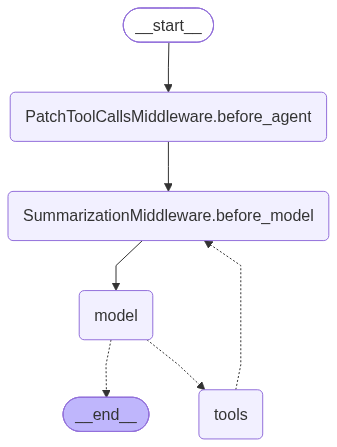

In [41]:
deep_agent

This cell demonstrates a **LangChain workflow component**. The key idea is to separate prompt construction, model execution, and output parsing so the pipeline stays modular and easier to test.

In [42]:
response = deep_agent.invoke(
    {"messages": [{"role": "user", "content": "What did the simulated assay report?"}]}
)

This notebook explains the main building blocks used in LangChain 1.x. The refreshed notes emphasize runnables, prompts, models, parsers, retrievers, and composition patterns rather than older chain abstractions.

In [43]:
response

{'messages': [HumanMessage(content='What did the simulated assay report?', additional_kwargs={}, response_metadata={}, id='7c0d272f-dbcc-4a1f-9219-b2452529e3cc'),
  AIMessage(content='I don’t have the specific simulated assay report you’re referring to. Could you share the report or tell me where it’s stored? If you want, I can also help you build an structured summary and an evidence map once I have the data.\n\nIn the meantime, here’s a concrete way to think about “what the simulated assay reported” and how we could present it with uncertainty preserved:\n\nPossible components of a simulated assay report\n- Objective and context\n- Assay type and target (what was simulated, e.g., binding assay, activity assay, qPCR, etc.)\n- Simulation setup\n  - Model assumptions\n  - Parameters used (concentrations, pH, temperature, etc.)\n  - Number of runs or iterations and whether there were replicates\n- Readout details\n  - Measured metric (e.g., signal intensity, EC50, IC50, Ct value)\n  - Un

This notebook explains the main building blocks used in LangChain 1.x. The refreshed notes emphasize runnables, prompts, models, parsers, retrievers, and composition patterns rather than older chain abstractions.

In [44]:
response["messages"][-1]

AIMessage(content='I don’t have the specific simulated assay report you’re referring to. Could you share the report or tell me where it’s stored? If you want, I can also help you build an structured summary and an evidence map once I have the data.\n\nIn the meantime, here’s a concrete way to think about “what the simulated assay reported” and how we could present it with uncertainty preserved:\n\nPossible components of a simulated assay report\n- Objective and context\n- Assay type and target (what was simulated, e.g., binding assay, activity assay, qPCR, etc.)\n- Simulation setup\n  - Model assumptions\n  - Parameters used (concentrations, pH, temperature, etc.)\n  - Number of runs or iterations and whether there were replicates\n- Readout details\n  - Measured metric (e.g., signal intensity, EC50, IC50, Ct value)\n  - Units and baseline/controls\n- Results\n  - Central tendency (mean/median) and variability (SD, IQR)\n  - Confidence intervals or credible intervals (if Bayesian)\n  -

This notebook explains the main building blocks used in LangChain 1.x. The refreshed notes emphasize runnables, prompts, models, parsers, retrievers, and composition patterns rather than older chain abstractions.

## Exercises

Use these tasks to test understanding before moving on. Expand each spoiler only after you have tried the problem yourself.

### Exercise 1
**Task:** Rewrite an older chain-style workflow as a Runnable pipeline.

<details><summary>Show sample answer</summary>

A typical rewrite is `prompt | model | parser`, with optional branching, mapping, or retrieval steps inserted as additional runnable nodes.

</details>

### Exercise 2
**Task:** Why is separating prompts, models, and parsers useful?

<details><summary>Show sample answer</summary>

The separation makes the pipeline easier to test, replace, and compose. You can swap models or output formats without rewriting the entire application.

</details>

### Exercise 3
**Task:** What is one advantage of using retrievers as independent components?

<details><summary>Show sample answer</summary>

Independent retrievers let you evaluate retrieval quality separately from generation quality, which makes debugging much easier.

</details>

---

## Open-ended research tasks

These go beyond the worked examples. There is no single correct answer — the goal is to build intuition about real design trade-offs.

### Task A — Structured output under a budget
Take the `PatientAssessment` parser and run it against **two different providers** from the `API_KEY_PROVIDER` switcher (e.g. OpenAI vs Groq). Compare: (1) how often the output parses cleanly into the Pydantic model, (2) latency, and (3) cost per call. Record your findings in a small manifest like `RUN_METADATA`. Which provider would you pick for a production triage tool, and why?

### Task B — From `create_agent` to a Deep Agent
The Deep Agents section used `create_deep_agent` with a single `search_synthetic_evidence` tool. Extend it with a **second tool** (e.g. a calculator, a unit converter, or a mock patient-record lookup). Observe how the agent plans across tools. Then add a guardrail system prompt that forces the agent to **abstain** ("insufficient evidence") when the tools return nothing relevant. Test that the abstention actually triggers.

### Task C — Few-shot vs. structured output
The few-shot medical-reasoning example relies on prompt engineering, while the Pydantic section relies on schema enforcement. Pick one clinical question and answer it **both ways**. Which approach gives more reliably machine-readable output? Which gives more transparent reasoning? When would you combine them (e.g. few-shot *inside* a structured-output chain)?

### Task D — Runnable composition for a real workflow
Using `RunnableLambda` and `RunnableParallel` (as in the temperature-conversion example), sketch a runnable graph for a **life-science task of your choice** — e.g. "given a SMILES string, compute its properties *and* retrieve similar known compounds *in parallel*, then summarize." You don't need live tools; stub the steps with lambdas. What does running the steps in parallel buy you over a sequential chain?

---
### Further Reading

| Notebook | Relevance |
|----------|-----------|
| **Chapter 3 Simple Pipeline-4** | End-to-end RAG pipeline using the components from this notebook |
| **Chapter 3 Typed Scientific Tools** | Pydantic v2 tool contracts with validated I/O |
| **Chapter 5 Building Personal Assistants LangGraph and Agents** | Full LangGraph agents built from typed tools |
